# Customer Behaviour Analysis
## Objective
**Analyse customer transactions and behaviour to identify customer segments, understand purchase patterns, and evaluate churn risks. Provide actionable business recommendations for Alfido Tech using data analysis and visualization.**


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load dataset

df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
# Display basic information about the dataset

print("Shape of the dataset:",df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())


Shape of the dataset: (250000, 13)

Column Names:
Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

First 5 Rows:


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
# Dataset information
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB
None


In [5]:
# Check for missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [6]:
print(df["Returns"].value_counts(dropna=False))

Returns
0.0    101635
1.0    100769
NaN     47596
Name: count, dtype: int64


In [7]:
# Check for duplicate rows

print("Number of duplicate rows:",df.duplicated().sum())


Number of duplicate rows: 0


### Observation
- The dataset contains **0 duplicate rows**.
- No duplicate records were removed during data cleaning process.

In [8]:
# Display data types

print(df.dtypes)

Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object


In [9]:
# Convert Purchase Date to datetime

df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

print("Purchase Date converted successfully!")

Purchase Date converted successfully!


In [10]:
# Check if 'Customer Age' and 'Age' are identical
print((df["Customer Age"]==df["Age"]).all())

True


In [11]:
# Remove the duplicate age column

df.drop(columns=["Age"],inplace=True)
print("Age column removed successfully!")

Age column removed successfully!


# Exploratory Data Analysis (EDA)


In [12]:
# Summary statistics for numerical columns
display(df.describe())

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.497861,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.499997,0.399622


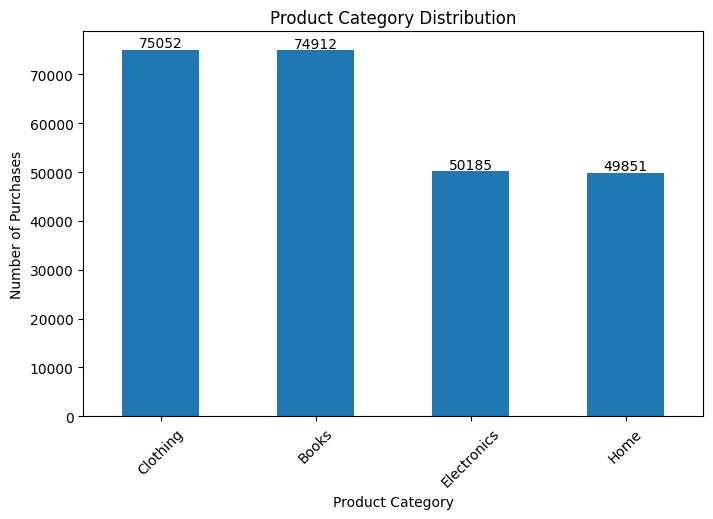

In [13]:
# Product Category Distribution

category_counts=df["Product Category"].value_counts()

plt.figure(figsize=(8,5))
ax = category_counts.plot(kind="bar")

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Purchases")

for i, value in enumerate(category_counts): plt.text(i,value +500,
str(value), ha='center')

plt.xticks(rotation=45)

plt.show()

### Observation
- Clothing is the **most** purchased product category(75,052), making it the most popular product category.
- Books also recorded a high purchase frequency(74,912).
- Electronics(50,185) and Home(49,851) categories have comparatively fewer purchases.
- The results indicate stronger customer demand for Clothing and Books.Therefore, Company may focus on promotional strategies for Electronics and Home to increase sales.


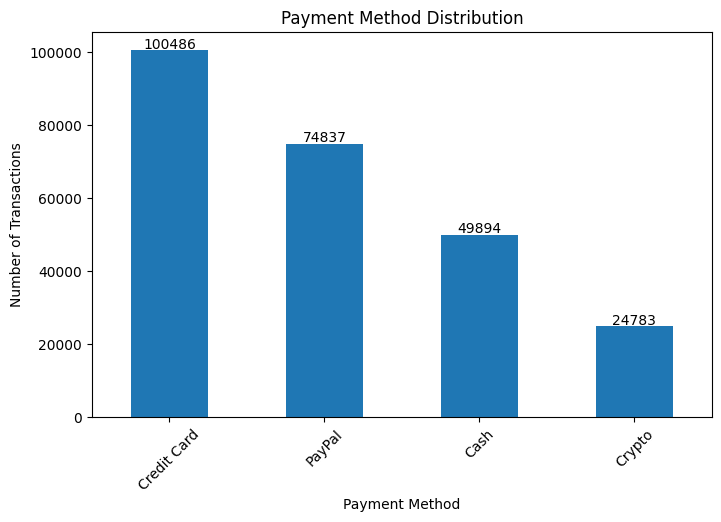

In [14]:
# Payment Method Distribution

payment_counts=df["Payment Method"].value_counts()

plt.figure(figsize=(8,5))
ax = payment_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

for i, value in enumerate(payment_counts): plt.text(i,value +500,
str(value), ha='center')

plt.xticks(rotation=45)

plt.show()


### Observation
- Credit Card is the **most preferred** payment method, accounting for 100,486 transactions.
- PayPal is the second **most popular** payment method with 74,837 transactions.
- Cash recorded 49,894 transactions, indicating a **lower preference** than digital payment methods.
- Cryptocurrency is the **least used** payment method, with only 24,783 transactions.
- The results suggest that customers strongly prefer digital payment methods. Therefore, the Company should continue enhancing digital payment options while evaluating whether additional incentives are needed to increase the adoption of cryptocurrency payments.

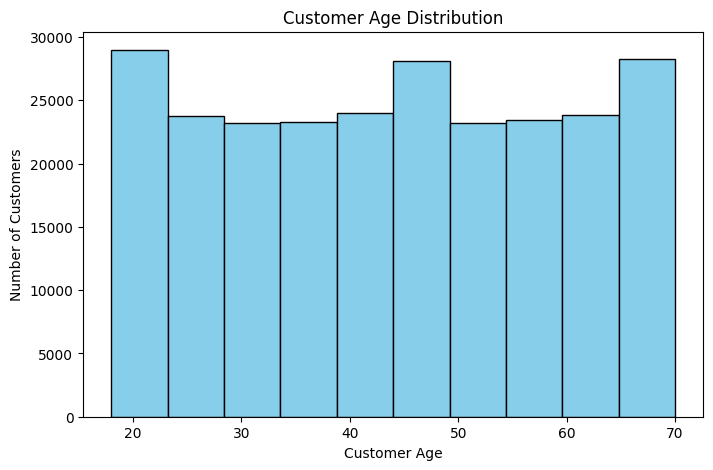

In [15]:
# Customer Age Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Customer Age"],bins=10,color="skyblue",edgecolor="black")

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

### Observation
- Customer ages range from 18 to 70 years.
- The age distribution is **fairly uniform** across different age groups, with no single age group dominating the customer base.
- There is no obvious gaps or unusual spikes in the distribution.
- The results suggest that the Company's products reach to customers across abroad range of ages. Therefore, marketing strategies can be designed for a multiple age groups rather than focusing on a single age segment.  

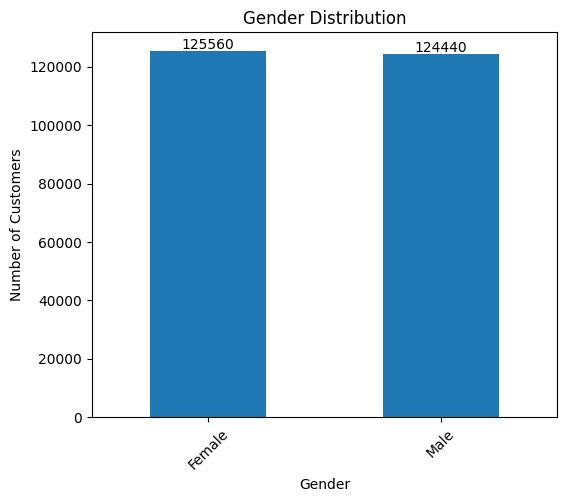

In [16]:
# Generate Distribution

gender_counts=df["Gender"].value_counts()

plt.figure(figsize=(6,5))
ax = gender_counts.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for i, value in enumerate(gender_counts): plt.text(i,value +500,
str(value), ha='center')

plt.xticks(rotation=45)

plt.show()

### Observation
- The dataset contains 125,560 female customers and 124,440 male customers.
- The gender distribution is nearly **balanced**, with female customers only slightly outnumbering male customers.
- There is no significant gender imbalance in the customer base.
- The results suggest that the Company's product reach to both male and female customers.
Therefore, marketing campaigns can be designed to target both genders rather than focusing predominantly on one.

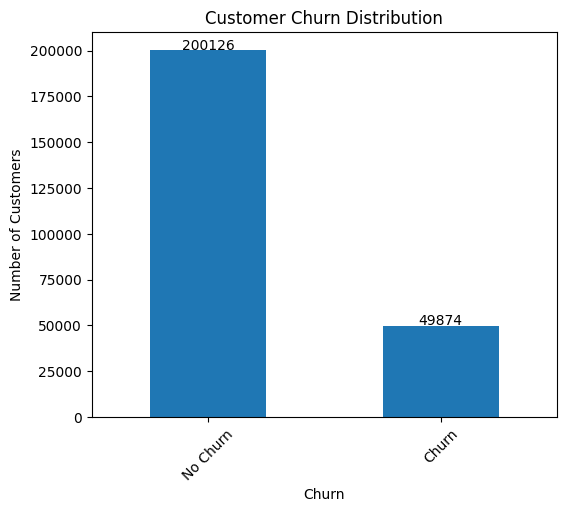

In [17]:
# Churn Distribution

churn_counts=df["Churn"].value_counts()

plt.figure(figsize=(6,5))
ax = churn_counts.plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts): plt.text(i,value +500,
str(value), ha='center')

plt.xticks(rotation=45)
plt.xticks([0,1],["No Churn","Churn"])

plt.show()

### Observation

- The dataset contains 200,126 customers who did not churn and 49,874 customers who churned.
- Approximately 80% of customers were retained, while around 20% discontinued their relationship with the Company.
- The customer retention rate is considerably **higher** than the churn rate, indicating that the Company retains the majority of its customers.
- However, the churned customers represent a significant proportion of the customer base. Therefore, the Company should investigate the factors contributing to customer churn and implement targeted retention strategies to improve customer loyalty.

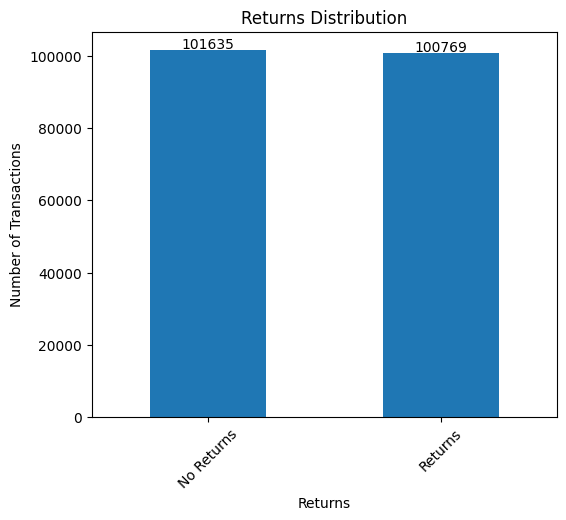

In [18]:
# Returns Distribution

returns_counts=df["Returns"].value_counts()

plt.figure(figsize=(6,5))
ax = returns_counts.plot(kind="bar")

plt.title("Returns Distribution")
plt.xlabel("Returns")
plt.ylabel("Number of Transactions")

for i, value in enumerate(returns_counts): plt.text(i,value +500,
str(value), ha='center')

plt.xticks(rotation=45)
plt.xticks([0,1],["No Returns","Returns"])

plt.show()



### Observation
- Among the transactions with known return status, 101,635 transactions had no returns, while 100,769 transactions resulted in returns.
- The numbers of returned and non-returned transactions are nearly equal, indicating a **balanced** distribution.
- Approximately 47,596 transactions have missing return information and are not included in this visualization.
- The high number of returned transactions suggests that the Company should investigate the reasons for product returns, such as product quality, customer expectations, or delivery issues, to improve customer satisfaction and reduce return rates.

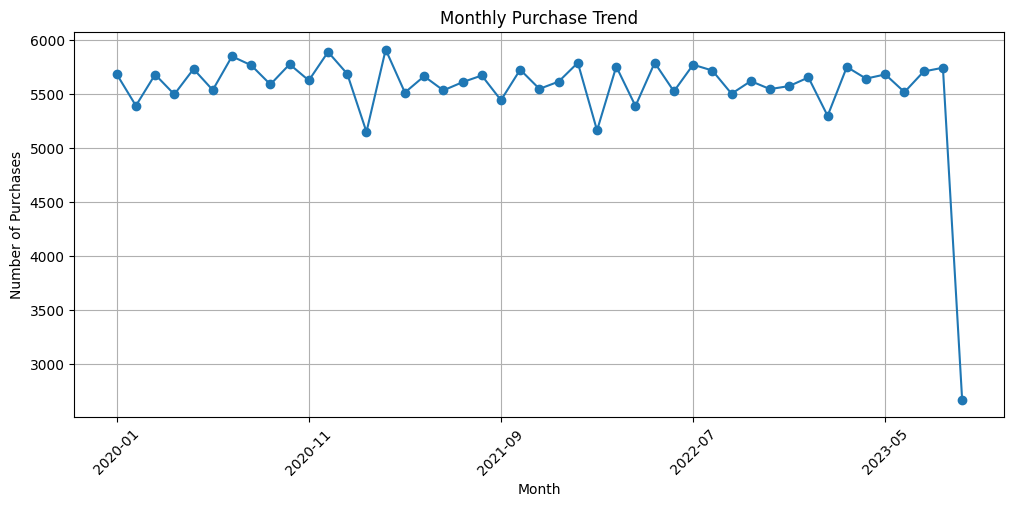

In [19]:
# Monthly Purchase Trend

df["Month"] = df["Purchase Date"].dt.to_period("M").astype(str)
monthly_purchases = df["Month"].value_counts().sort_index()

plt.figure(figsize=(12,5))
monthly_purchases.plot(kind="line", marker="o")

plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation
- Monthly purchases remained relatively **stable** throughout the study period, generally ranging between 5,300 and 5,900 transactions.
- The line chart shows only minor month-to-month fluctuations, indicating **consistent** customer purchasing behaviour over time.
- The final month shows a **sharp decline** in the number of purchases. This is likely because the dataset contains only a partial month's data rather than a complete month.
- Overall, the Company experienced a **stable** purchase trend during the observed period, suggesting consistent customer engagement.

# Customer Segmentation using RFM Analysis

In [20]:
# Create reference date for Recency calculation

reference_date = df["Purchase Date"].max() + pd.Timedelta(days=1)

In [21]:
# Create RFM table

rfm= df.groupby("Customer ID").agg({"Purchase Date":lambda x: (reference_date - x.max()).days,"Customer ID":"count","Total Purchase Amount":"sum"})

rfm.columns = ["Recency","Frequency","Monetary"]

display(rfm.head())

,Recency,Frequency,Monetary
Customer ID,,,
1,58,1,3491
2,299,3,7988
3,89,8,22587
4,127,4,8715
5,171,8,12524


In [22]:
rfm["R_Score"] = pd.qcut(rfm["Recency"],4,labels=[4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),4,labels=[1,2,3,4,])
rfm["M_Score"] = pd.qcut(rfm["Monetary"],4,labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

display(rfm.head())

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
1,58,1,3491,4,1,1,411
2,299,3,7988,2,1,1,211
3,89,8,22587,3,4,4,344
4,127,4,8715,3,2,1,321
5,171,8,12524,3,4,2,342


In [23]:
def segment_customer(row):
   if row["R_Score"] >=3 and row["F_Score"] >=3 and row["M_Score"] >=3: return "High Value"
   elif row["R_Score"] >=3 and row["F_Score"] >=3: return "Loyal"
   elif row["R_Score"] >=3: return "Potential"
   elif row["R_Score"] <=2 and row["F_Score"] >=3: return "At Risk"
   else:return "Low Value"

rfm["Segment"] = rfm.apply(segment_customer,axis=1)

display(rfm.head())

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer ID,,,,,,,,
1,58,1,3491,4,1,1,411,Potential
2,299,3,7988,2,1,1,211,Low Value
3,89,8,22587,3,4,4,344,High Value
4,127,4,8715,3,2,1,321,Potential
5,171,8,12524,3,4,2,342,Loyal


In [24]:
# Count customers in each segment

segment_counts = rfm["Segment"].value_counts()

display(segment_counts)

,count
Segment,
Low Value,15431
High Value,13155
Potential,9406
At Risk,9384
Loyal,2297


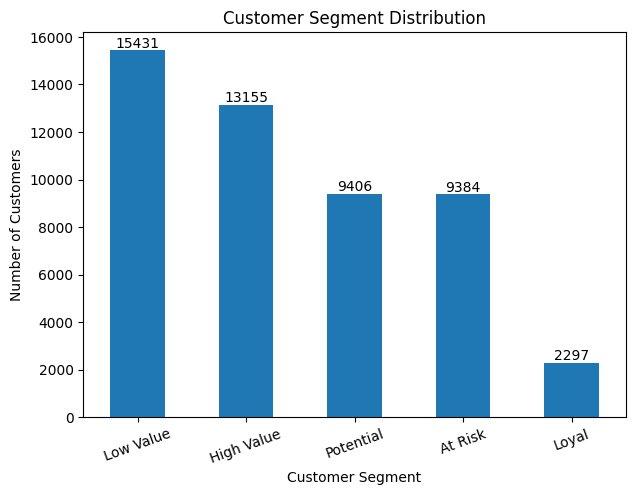

In [25]:
plt.figure(figsize=(7,5))

segment_counts.plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, value in enumerate(segment_counts):plt.text(i,value+100, str(value),ha="center")

plt.xticks(rotation=20)

plt.show()

### Observation
- **Low Value customers** form the largest customer segment (15,431 customers).
- **High Value customers** are second-largest segment(13,155 customers), indicating a strong base of valuable customers.
- The numbers of **Potential**(9,406) and **At Risk** (9,384) customers are almost equal.
- **Loyal customers** (2,297) represent the smallest segment, suggesting there is room to improve customer retention.
- The Company should focus on converting Potential customers while implementing retention strategies for At Risk customers and maintaining relationships with High Value customers.   

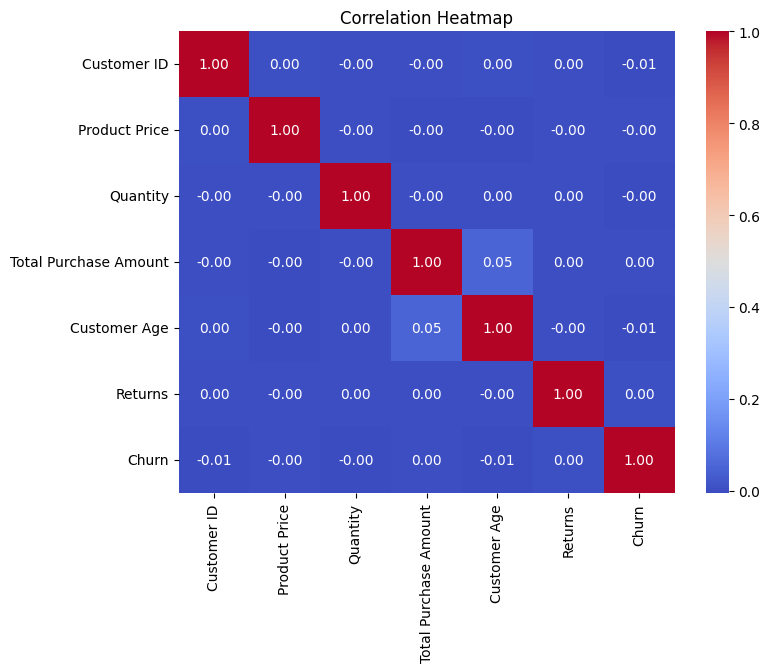

In [26]:
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap (corr,annot= True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observation
- Most numerical variables show very weak or no correlation with one another, as most correlation coefficients are close to 0.
- There is a very weak positive correlation (0.05) between Customer Age and Total Purchase Amount, suggesting that age has little influence on spending.
- Product Price, Quantity, Returns, and Churn do not exhibit any strong linear relationships with the other numerical variables.
- The absence of strong correlations indicates that customer purchasing behavior is influenced by multiple factors rather than a single numerical variable.
- This suggests that businesses should rely on customer segmentation and behavioral analysis, rather than individual variables alone, to understand purchasing patterns and improve marketing strategies.  

# Business Recommendations

1. **Retain High-Value Customers:** Introduce loyalty programs, exclusive discounts, and personalized offers to strengthen relationships with high-value customers.
2. **Convert Potential Customers**: Target potential customers with personalized promotions and product recommendations to encourage repeat purchases.
3. **Reduce Customer Churn:** Identify at-risk customers early and engage them through follow-up emails, special offers, and improved customer support.
4. **Boost Sales of Low-Demand Categories:** Increase sales of Electronics and Home products through discounts, bundle offers, and targeted marketing campaigns.
5. **Use Customer Segmentation for Marketing:** Regularly apply RFM analysis to segment customers and design personalized marketing strategies for different customer groups.

# Conclusion

This analysis explored customer purchasing behavior using exploratory data analysis (EDA) and RFM segmentation techniques. The results showed that Clothing and Books are the most purchased product categories, while Credit Card is the most preferred payment method. The customer base is diverse in terms of age and gender, with relatively low churn and balanced return rates. RFM analysis successfully identified different customer segments, including High Value, Loyal, Potential, At Risk, and Low Value customers. These insights can help the company improve customer retention, personalize marketing strategies, and make data-driven business decisions to enhance overall business performance.